In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from load_meop import MEOP
from region import Region
pfns = PlottingFns()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
import xesmf as xe
import matplotlib.patches as mpatches


glaciers = {'mertz ':[144.25,-67.5],
            'denman':[99.5, -66.75],
            'conger':[103,-66],
            'vanderford':[110, -66],
            'totten':[116.33,-67],
            'cook': [153,-69],
            'voyeykov': [124.5,-66.33]}

In [4]:
#define helper functions
def get_trend(da: xr.DataArray,ns=True):
    ns_2_yr = lambda x: x * 1e9 * 60 * 60 * 24 * 365.25
    p = da.polyfit(dim='time',deg=1)
    m = p.polyfit_coefficients.sel(degree=1)
    m = m.assign_coords(longitude=da.longitude)
    return ns_2_yr(m) if ns else m

def crop_to_extent(ds, extent):
    return ds.where((ds.latitude >= extent[2]) & 
                    (ds.latitude <= extent[3]) &
                    (ds.longitude >= extent[0]) &
                    (ds.longitude <= extent[1]), drop=True)

def season_split(da):
    # divide by season
    months = da.time.dt.month
    seasons = dict()
    seasons['winter'] = da.where((months >=7) & (months <=9))
    seasons['spring'] = da.where((months >=10) & (months <=12))
    seasons['summer'] = da.where((months >=1) & (months <=3))
    seasons['autumn'] = da.where((months >=4) & (months <=6))
    return seasons

def seasonal_anomaly(da):
    return da.groupby('time.month') - da.groupby('time.month').mean()

def plot_glaciers(ax):
    for label in glaciers:
        coords=glaciers[label]
        ax.text(coords[0],coords[1],label,transform=ccrs.PlateCarree(),size=8,c='w',ha='center',bbox=dict(boxstyle="square",facecolor='black',alpha=0.5))



In [5]:
sice = xr.open_dataset('../data/NSIDC/sice_processed.nc')
sice = sice.__xarray_dataarray_variable__

In [6]:
lwe_ds = GRACE().ds
sla = SLA(deg=1).da
sla0 = SLA(deg=0.25).da
dot_ds = DOT().ds

In [7]:
sice = sice.sel(time=slice(sla.time[0],sla.time[-1]))
sica = sice.groupby('time.month') - sice.groupby('time.month').mean()

In [8]:
elevation_fine = GEBCO(coarsen_factor=1).ds
elevation = elevation_fine.coarsen(latitude=40,longitude=40).mean().elevation

In [9]:
mertz_local = [141,144,-68.5,-66.5]
adelie = [130,150,-68.5,-64]
east_antarctica = [70,180,-72,-60]
mid_antarctica = [-60,70,-85,-60]
west_antarctica = [-180,-60,-85,-60]
southern_ocean = [-180,180,-90,-50]
r1 = [60,90,-70,-60]
r2 = [90,120,-70,-60]
r3 = [120,150,-70,-60]
r4 = [150,170,-70,-60]

In [10]:
# crop elevation
elevation_mertz = elevation_fine.sel(latitude = slice(-70,-65), longitude = slice(132,148)).elevation

In [11]:
sha_ds_sla = StericHeight(ssh_ref='DOT',
                      ssh=sla,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()


sha_ds_dot = StericHeight(ssh_ref='DOT',
                      ssh=dot_ds.dot,
                      msl=None,
                      lwe=lwe_ds.lwe_thickness
                      ).get_sha()

In [12]:
an = lambda da: da.groupby('time.year').mean()
yr = lambda da: [pd.Timestamp(y.item(),1,1) for y in an(da).year]

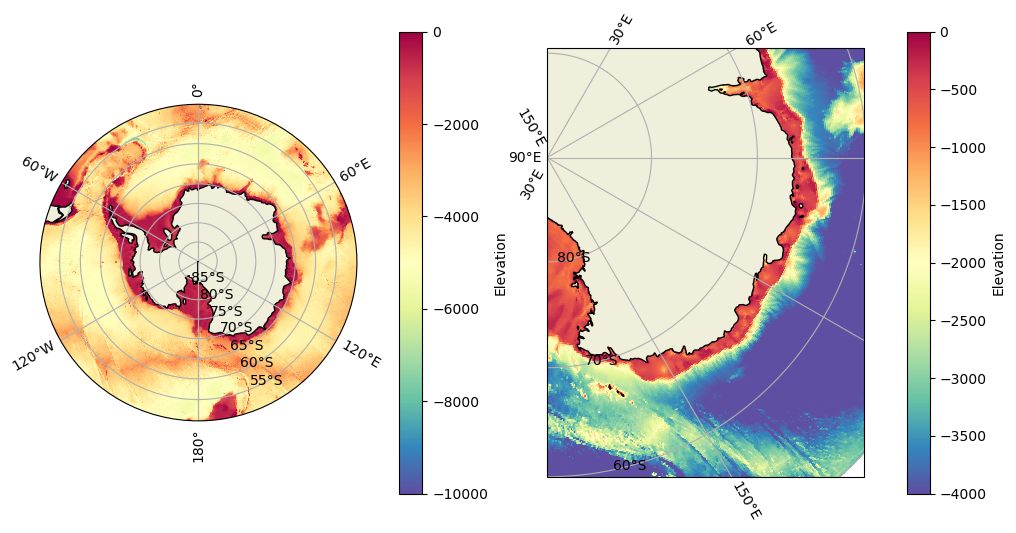

In [ ]:

fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],elevation,cbar='Elevation',vmax=0,vmin=-4000,cbar_orientation='vertical',land_zorder=2,cmap=cmocean.cm.deep)
pfns.sp(ax[1],elevation,cbar='Elevation',vmax=0,vmin=-4000,extent=east_antarctica,cbar_orientation='vertical',land_zorder=2)



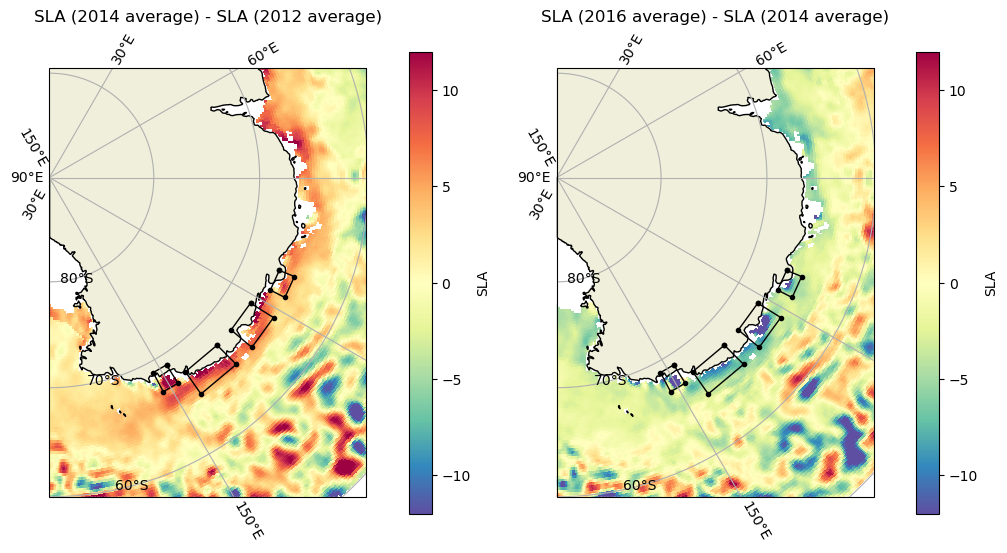

In [ ]:
# define patches
patches = {
    'cook': [148,152,-69,-67],
    'mertz': [135,145,-67.5,-65],
    'voyeykov': [122,130,-67.5,-65],
    'totten': [112,117,-66.5,-65]}

fig, ax = plt.subplots(1,2,figsize=(12,6),subplot_kw={'projection':ccrs.SouthPolarStereo()})
pfns.sp(ax[0],an(sla0).sel(year=2014)-an(sla0).sel(year=2012),cbar='SLA',vmax=12,title='SLA (2014 average) - SLA (2012 average)',extent=east_antarctica,cbar_orientation='vertical',land_zorder=2)
pfns.sp(ax[1],an(sla0).sel(year=2016)-an(sla0).sel(year=2014),cbar='SLA',vmax=12,title='SLA (2016 average) - SLA (2014 average)',extent=east_antarctica,cbar_orientation='vertical',land_zorder=2)

for p in patches:
    coords = patches[p]
    x1 = coords[0]
    x2 = coords[1]
    y1 = coords[2]
    y2 = coords[3]
    ax[0].plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1],
         color='black', linewidth=1, marker='.',
         transform=ccrs.Geodetic(), #remove this line to get straight lines
         )
    ax[1].plot([x1, x2, x2, x1, x1], [y1, y1, y2, y2, y1],
         color='black', linewidth=1, marker='.',
         transform=ccrs.Geodetic(), #remove this line to get straight lines
         )




Adding row: cook


Adding row: mertz
Adding row: voyeykov
Adding row: totten
Rendering..


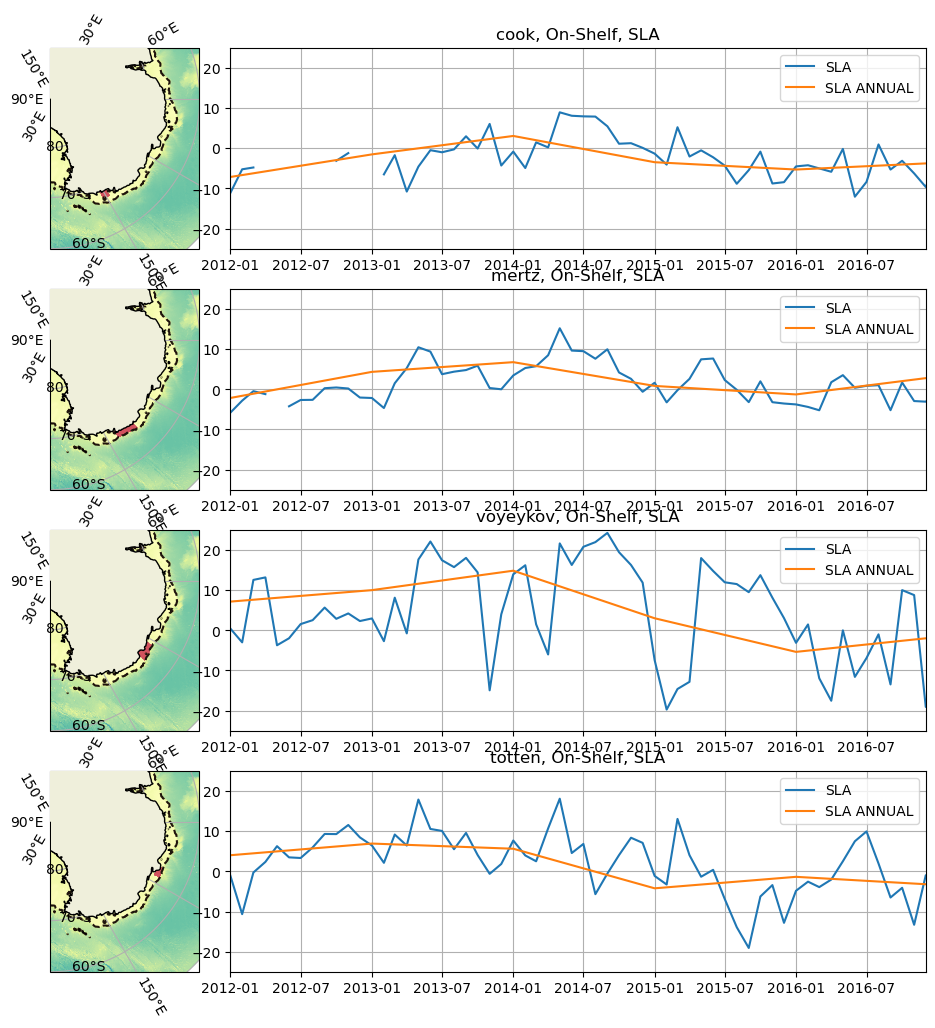

In [17]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,7)

def add_row(n,var1,var1name,title,extent,map_extent,shelf=False,var2=None,var2name=""):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*2],da=elevation,extent=map_extent)

    da1 = region.crop_da(var1)

    ax = axs[(n*2)+1]

    ax.plot(da1.time,da1.mean(['latitude','longitude']),label=var1name)
    ax.plot(yr(da1),an(da1).mean(['latitude','longitude']),label=var1name + ' ANNUAL')

    if var2 is not None:
        da2 = region.crop_da(var2)
        ax.plot(da2.time,da2.mean(['latitude','longitude']),label=var2name)
        ax.plot(yr(da2),an(da2).mean(['latitude','longitude']),label=var2name + ' ANNUAL')

    shelf_str = 'On' if shelf else 'On and Off'
    title_var1 = title +', '+shelf_str+'-Shelf, ' + var1name
    ax.set_title(title_var1 if var2 is None else (title_var1 + ' and ' + var2name))
    ax.legend(loc='best')
    ax.set_ylim([-25,25])
    ax.set_xlim([pd.Timestamp(2012,1,1),pd.Timestamp(2016,12,1)])
    ax.grid()

var = sha_ds_sla.ssha
nam = 'SLA'
for i,p in enumerate(patches):
    add_row(i,var,nam,p,patches[p],east_antarctica,shelf=True)  
print('Rendering..')


Adding row: cook


Adding row: mertz
Adding row: voyeykov
Adding row: totten
Rendering..


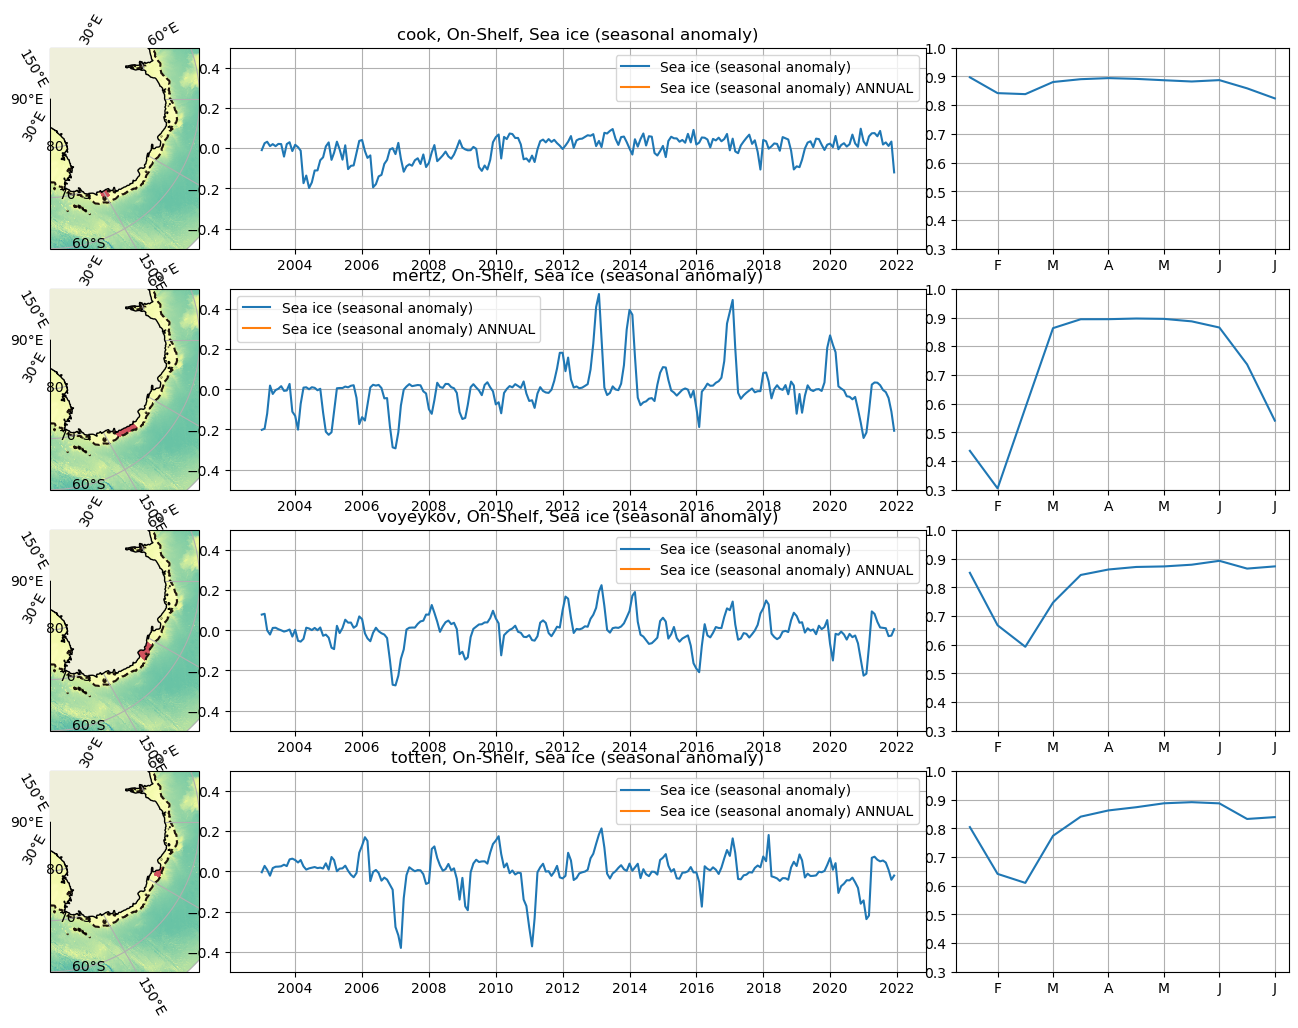

In [18]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,7)

def add_row_anom(n,var,varname,title,extent,map_extent,shelf=False):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))
    axs.append(fig.add_subplot(gs[n,5:7]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*3],da=elevation,extent=map_extent)

    da = region.crop_da(var)

    ax = axs[(n*3)+1]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm.mean(['latitude','longitude']),label=varname)
    ax.plot(yr(da),an(da).mean(['latitude','longitude']),label=varname + ' ANNUAL')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim([-0.5,0.5])
    #ax.set_xlim([pd.Timestamp(2012,1,1),pd.Timestamp(2016,12,1)])
    ax.grid()

    ax = axs[(n*3)+2]

    ax.plot(cmt.month,cmt.mean(['latitude','longitude']))
    ax.set_ylim([0.3,1])
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])

var = sice
nam = 'Sea ice'
for i,p in enumerate(patches):
    add_row_anom(i,var,nam,p,patches[p],east_antarctica,shelf=True)  
print('Rendering..')


In [19]:
winds = xr.open_dataset('ef25db236e60a21a34ee2e0b4631d366.nc')
wind_seasonal_anomaly = winds.groupby('valid_time.month') - winds.groupby('valid_time.month').mean()

In [20]:
winds_total_anomaly = winds - winds.sel(valid_time=slice(sha_ds_sla.time[0],sha_ds_sla.time[-1])).mean('valid_time')

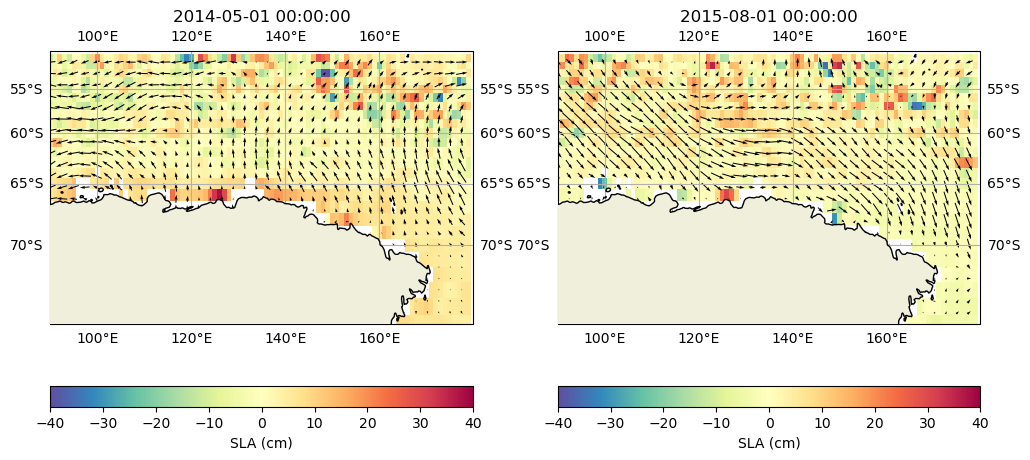

In [21]:
fig, axs = plt.subplots(1,2,figsize=(12,8),subplot_kw={"projection":ccrs.Mercator()})
extent = [90,180,-75,-50]

def plot_t(ax,t_sample):
    wind_sample =  crop_to_extent(winds_total_anomaly.sel(valid_time=t_sample,method='nearest'),extent)
    ssh_sample = crop_to_extent(sha_ds_sla.ssha.sel(time=t_sample),extent)

    pfns.sp(ax=ax,da=ssh_sample,extent=extent,cbar='SLA (cm)',cbar_orientation='horizontal',vmax=40)
    wind_sample.plot.quiver(x='longitude',y='latitude',u='u10',v='v10',ax=ax, transform=ccrs.PlateCarree(),regrid_shape=25)
    ax.set_title(str(t_sample))

plot_t(axs[0],pd.Timestamp(2014,5,1))
plot_t(axs[1],pd.Timestamp(2015,8,1))

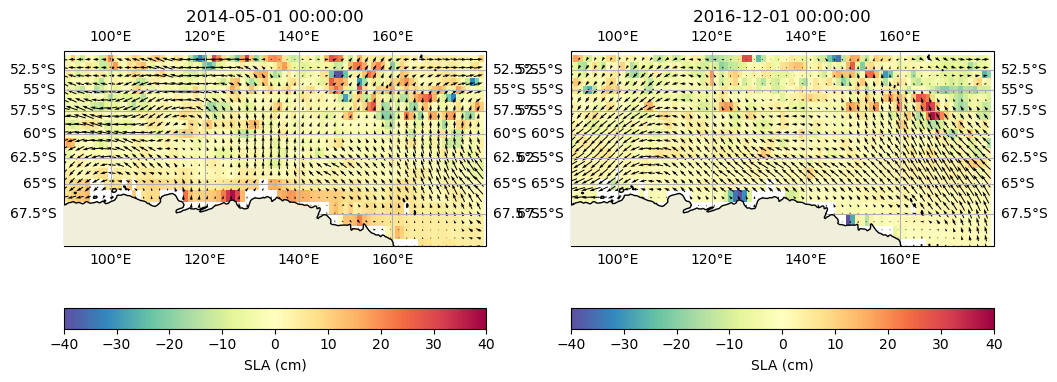

In [22]:
fig, axs = plt.subplots(1,2,figsize=(12,8),subplot_kw={"projection":ccrs.Mercator()})
extent = [90,180,-70,-50]

def plot_t(ax,t_sample):
    wind_sample =  crop_to_extent(wind_seasonal_anomaly.sel(valid_time=t_sample,method='nearest'),extent)
    ssh_sample = crop_to_extent(sha_ds_sla.ssha.sel(time=t_sample),extent)

    pfns.sp(ax=ax,da=ssh_sample,extent=extent,cbar='SLA (cm)',cbar_orientation='horizontal',vmax=40)
    wind_sample.plot.quiver(x='longitude',y='latitude',u='u10',v='v10',ax=ax, transform=ccrs.PlateCarree(),regrid_shape=25)
    ax.set_title(str(t_sample))

plot_t(axs[0],pd.Timestamp(2014,5,1))
plot_t(axs[1],pd.Timestamp(2016,12,1))

In [24]:
meop=MEOP(extent=patches['mertz'])

In [25]:
meop.load_profiles()
meop.df

100%|██████████| 85/85 [03:01<00:00,  2.14s/it]


,latitude,longitude,sst,gph
2007-02-20 15:19:59,-66.6190,139.9200,-0.960768,0.149898
2007-02-20 23:29:59,-66.5560,140.0420,-1.339080,0.161139
2007-02-21 04:40:00,-66.5868,140.0270,-1.206342,0.129097
2007-02-21 08:39:58,-66.5839,139.9780,-1.145038,0.171173
2007-02-21 17:29:59,-66.6441,140.0330,-1.155894,0.154512
...,...,...,...,...
2019-06-09 07:10:00,-66.6652,141.3514,NaN,NaN
2019-06-09 15:50:00,-66.6525,141.3284,-1.868499,0.028732
2019-06-10 06:59:59,-66.6272,141.2570,-1.869010,NaN
2019-06-11 00:10:00,-66.6434,141.3453,-1.872104,0.028544


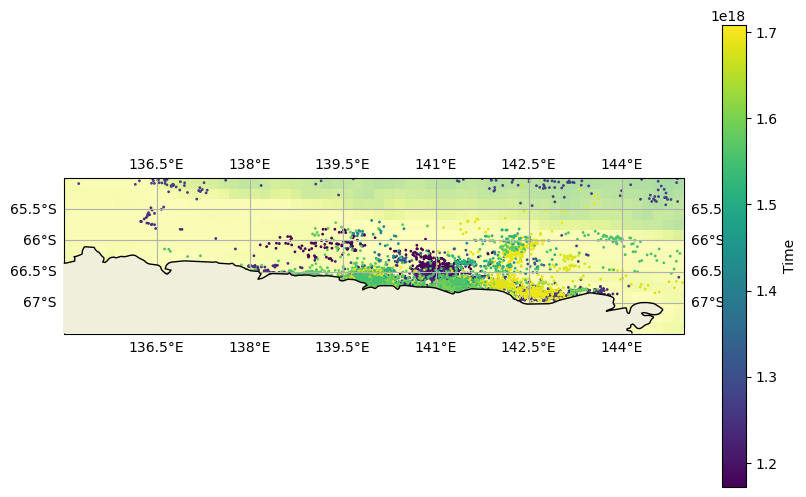

In [ ]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.PlateCarree()})
pfns.sp(ax=ax,da=elevation,extent=patches['mertz'])
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


<Axes: >

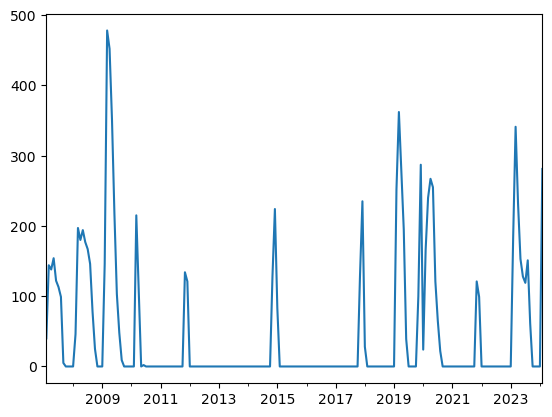

In [ ]:
meop_monthly = meop.df.groupby(pd.Grouper(freq='MS')).mean()
meop.df.groupby(pd.Grouper(freq='MS')).count().gph.plot()

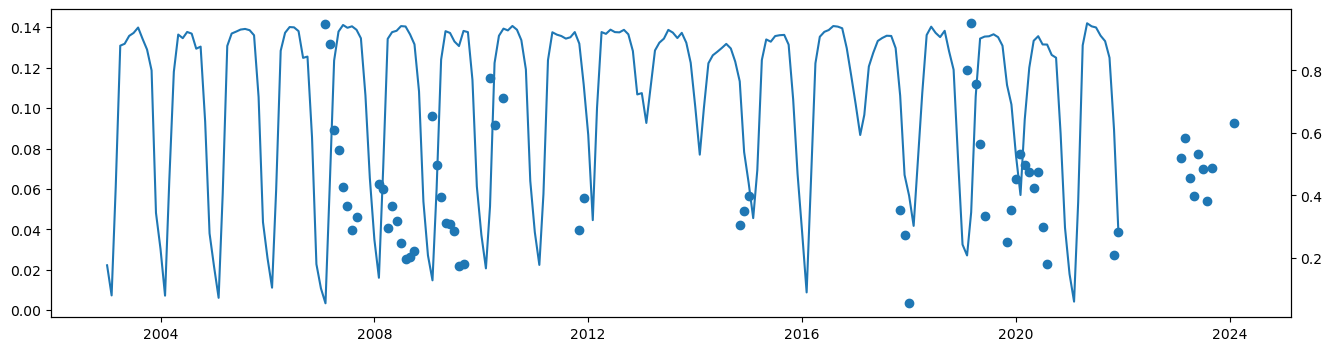

In [36]:
fig, ax = plt.subplots(figsize=(16,4))
img = ax.scatter(meop_monthly.index,meop_monthly.gph)
ax2 = ax.twinx()

sice_mertz = crop_to_extent(sice,patches['mertz'])
ax2.plot(sice_mertz.time,sice_mertz.mean(['latitude','longitude']))

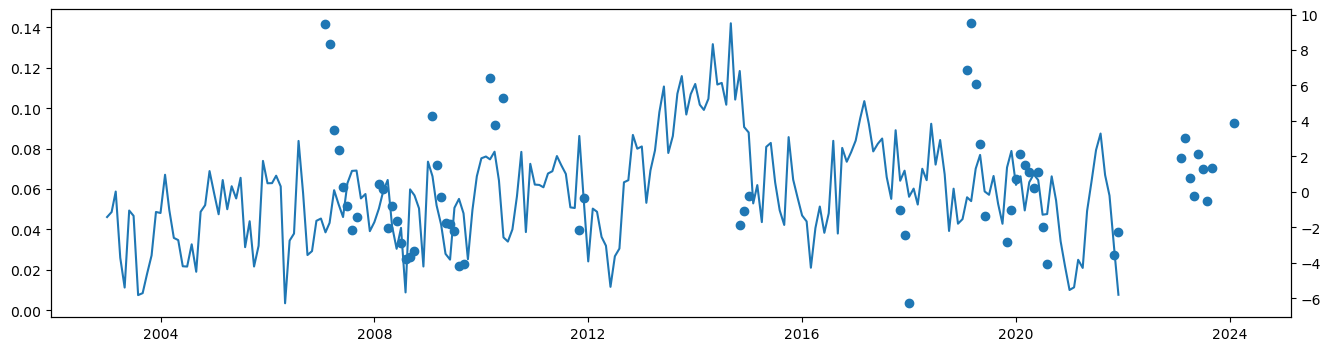

In [48]:
fig, ax = plt.subplots(figsize=(16,4))
img = ax.scatter(meop_monthly.index,meop_monthly.gph)
ax2 = ax.twinx()

sha_mertz = crop_to_extent(sla0,patches['mertz'])
sha_mertz = sha_mertz.groupby('time.month') - sha_mertz.groupby('time.month').mean()
ax2.plot(sha_mertz.time,sha_mertz.mean(['latitude','longitude']))

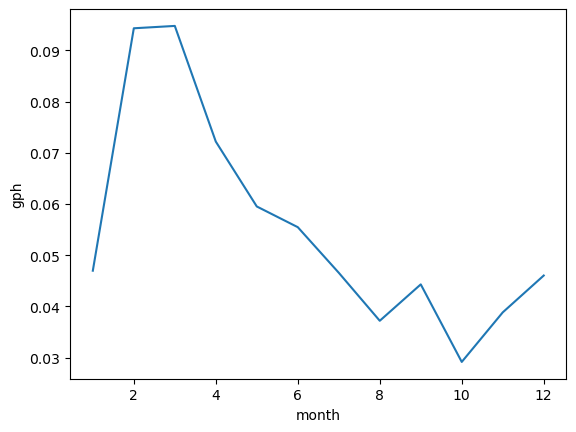

In [41]:
meop_cmt = meop.df.to_xarray().rename({'index':'time'}).groupby('time.month').mean()
meop_cmt.gph.plot()

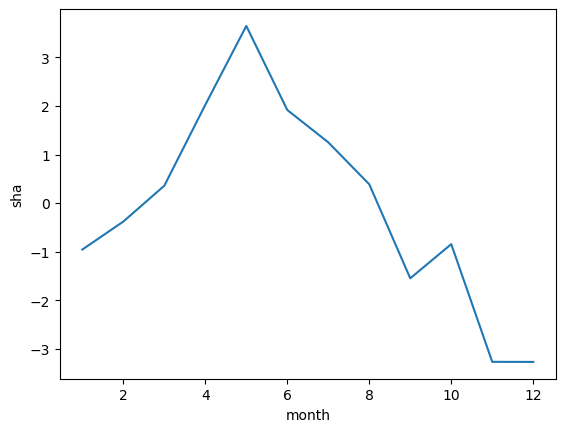

In [44]:
sha_cmt = sha_mertz.groupby('time.month').mean()
sha_cmt.mean(['latitude','longitude']).plot()

In [ ]:
# compare small mertz area to:
# - extended shelf region (135-145)
# - EA south of Amery
# - whole SO (shelf)
fig = plt.figure(figsize=(16,12))
axs=[]

gs = fig.add_gridspec(4,7)

def add_row_anom(n,var,varname,title,extent,map_extent,shelf=False):

    print('Adding row: ' + title)

    axs.append(fig.add_subplot(gs[n, 0],projection=ccrs.SouthPolarStereo()))
    axs.append(fig.add_subplot(gs[n,1:5]))
    axs.append(fig.add_subplot(gs[n,5:7]))

    if shelf == True:
        region = Region(title, extent, elevation, min_elevation = -1000)
    else:
        region = Region(title, extent, elevation)
    region.plot_region(ax=axs[n*3],da=elevation,extent=map_extent)

    da = region.crop_da(var)

    ax = axs[(n*3)+1]

    cmt = da.groupby('time.month').mean()
    anm = da.groupby('time.month') - cmt
    varname = varname + ' (seasonal anomaly)'

    ax.plot(anm.time,anm.mean(['latitude','longitude']),label=varname)
    ax.plot(yr(da),an(da).mean(['latitude','longitude']),label=varname + ' ANNUAL')

    shelf_str = 'On' if shelf else 'On and Off'
    ax.set_title(title +', '+shelf_str+'-Shelf, ' + varname)
    ax.legend(loc='best')
    ax.set_ylim([-0.5,0.5])
    #ax.set_xlim([pd.Timestamp(2012,1,1),pd.Timestamp(2016,12,1)])
    ax.grid()

    ax = axs[(n*3)+2]

    ax.plot(cmt.month,cmt.mean(['latitude','longitude']))
    ax.set_ylim([0.3,1])
    ax.grid()
    ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax.set_xlim([0.5,12.5])


add_row_anom(i,sha_ds_sla.ssha,'SLA','Mertz',patches['mertz'],east_antarctica,shelf=True)
add_row_anom(i,sha_ds_sla.sha,'SHA','Mertz',patches['mertz'],east_antarctica,shelf=True)
add_row_anom(i,sica,'SICA','Mertz',patches['mertz'],east_antarctica,shelf=True)
add_row_anom(i,meop.df.groupby(pd.Grouper(freq='MS')).mean().to_xarray(),'GPH','Mertz',patches['mertz'],east_antarctica,shelf=True)

print('Rendering..')


  0%|          | 0/9 [00:00<?, ?it/s]


ValueError: applied function returned data with an unexpected number of dimensions. Received 1 dimension(s) but expected 0 dimensions with names (), from:

array([ True,  True,  True, ...,  True,  True,  True])

In [93]:
meop=MEOP(extent=patches['voyeykov'])
meop.load_profiles()

100%|██████████| 33/33 [00:13<00:00,  2.49it/s]


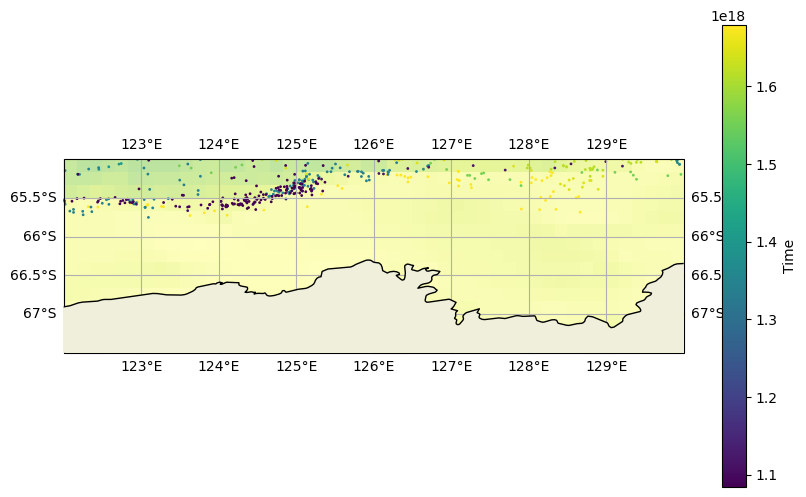

In [94]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.PlateCarree()})
pfns.sp(ax=ax,da=elevation,extent=patches['voyeykov'])
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')


In [95]:
meop=MEOP(extent=patches['totten'])
meop.load_profiles()

100%|██████████| 67/67 [00:26<00:00,  2.57it/s]


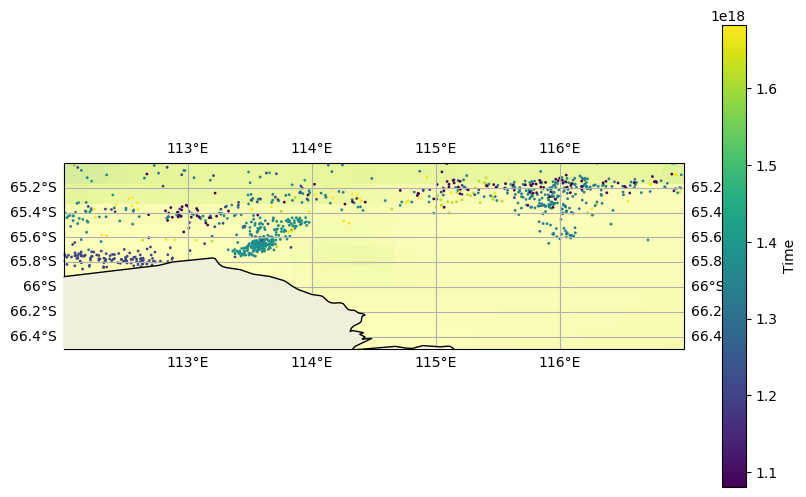

In [96]:
fig, ax = plt.subplots(figsize=(10,6), subplot_kw={'projection':ccrs.PlateCarree()})
pfns.sp(ax=ax,da=elevation,extent=patches['totten'])
im=ax.scatter(meop.df.longitude, meop.df.latitude, [1 for t in meop.df.index], meop.df.index, transform=ccrs.PlateCarree())
cbar = plt.colorbar(im, label='Time')

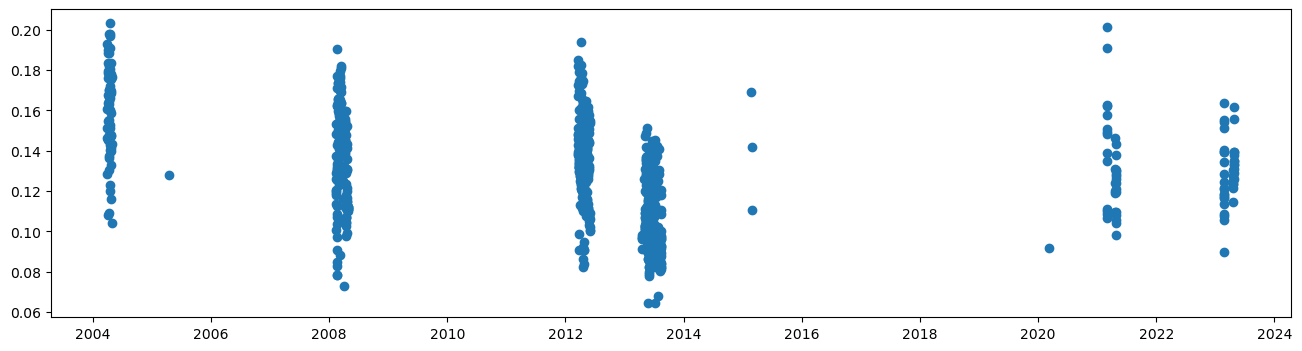

In [97]:
fig, ax = plt.subplots(figsize=(16,4))
img = ax.scatter(meop.df.index,meop.df.gph) 